Dataset Ready
Found 2520 images belonging to 3 classes.
Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.
Found 372 images belonging to 3 classes.
Training Model WITHOUT Augmentation...
Training Model WITH Augmentation...


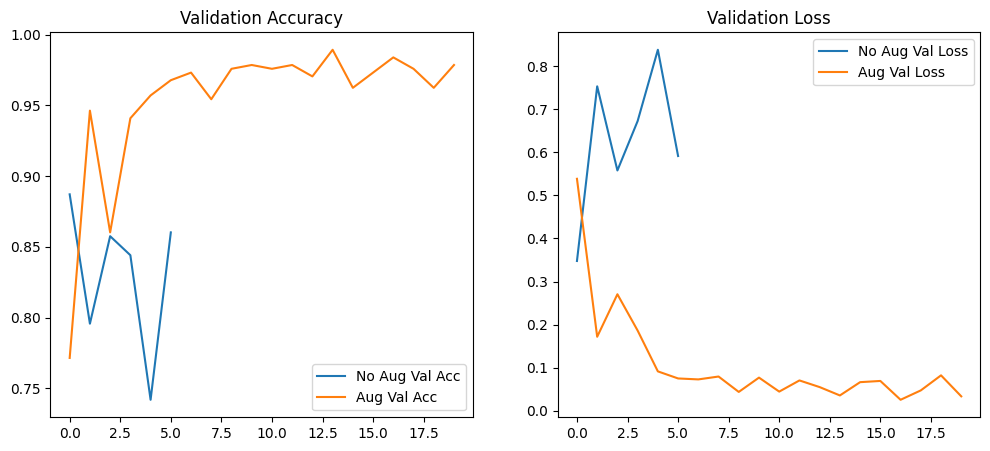

In [2]:
import os
import zipfile
import requests
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- 1. Data Setup ---
IMG_SIZE = (150, 150)
BATCH = 32
EPOCHS = 20

# Download and extract data if not present
base_dir = 'data/rock-paper-scissors'
os.makedirs(base_dir, exist_ok=True)

if not os.path.exists(f'{base_dir}/train'):
    print('Downloading datasets...')
    urls = [
        ('rps.zip', 'https://storage.googleapis.com/learning-datasets/rps.zip'),
        ('rps-test.zip', 'https://storage.googleapis.com/learning-datasets/rps-test-set.zip')
    ]
    for name, url in urls:
        path = f'data/{name}'
        with open(path, 'wb') as f: f.write(requests.get(url).content)
        with zipfile.ZipFile(path, 'r') as z: z.extractall('data/temp')

    shutil.move('data/temp/rps', f'{base_dir}/train')
    shutil.move('data/temp/rps-test-set', f'{base_dir}/test')
    shutil.copytree(f'{base_dir}/test', f'{base_dir}/valid')
    shutil.rmtree('data/temp', ignore_errors=True)
    print('Dataset Ready')

train_dir, valid_dir, test_dir = f'{base_dir}/train', f'{base_dir}/valid', f'{base_dir}/test'

# --- 2. Data Generators ---
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
scale_datagen = ImageDataGenerator(rescale=1./255)

flow_kwargs = dict(target_size=IMG_SIZE, batch_size=BATCH, class_mode='categorical')
train_data = scale_datagen.flow_from_directory(train_dir, shuffle=True, seed=42, **flow_kwargs)
train_data_aug = train_datagen.flow_from_directory(train_dir, shuffle=True, seed=42, **flow_kwargs)
val_data = scale_datagen.flow_from_directory(valid_dir, shuffle=False, **flow_kwargs)
test_data = scale_datagen.flow_from_directory(test_dir, shuffle=False, **flow_kwargs)

# --- 3. Model Definition ---
def build_model():
    return Sequential([
        Input((*IMG_SIZE, 3)),
        Conv2D(16, 3, padding='same', activation='relu'),
        MaxPooling2D(),
        Conv2D(32, 3, padding='same', activation='relu'),
        MaxPooling2D(),
        Conv2D(64, 3, padding='same', activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])

model_no_aug = build_model()
model_aug = build_model()
model_no_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- 4. Training ---
os.makedirs('chkpoints', exist_ok=True)
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training Model WITHOUT Augmentation...")
history_no_aug = model_no_aug.fit(train_data, validation_data=val_data, epochs=EPOCHS, verbose=0, callbacks=[es])

print("Training Model WITH Augmentation...")
history_aug = model_aug.fit(train_data_aug, validation_data=val_data, epochs=EPOCHS, verbose=0, callbacks=[es])

# --- 5. Visualization ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.plot(history_no_aug.history['val_accuracy'], label='No Aug Val Acc'); plt.plot(history_aug.history['val_accuracy'], label='Aug Val Acc'); plt.title('Validation Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(history_no_aug.history['val_loss'], label='No Aug Val Loss'); plt.plot(history_aug.history['val_loss'], label='Aug Val Loss'); plt.title('Validation Loss'); plt.legend()
plt.show()